In [2]:
import os
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from torchvision import models, transforms

IMAGE_DIR = "subj01/training_split/training_images"
SAVE_PATH = "resnet_conv3_features.pkl"
DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)


model = models.resnet50(pretrained=True)
model = model.to(DEVICE)
model.eval()


features = {
    "layer1_conv3": [],
    "layer4_conv3": []
}

def get_hook(name):
    def hook(module, input, output):
        features[name].append(output.detach().cpu())
    return hook


model.layer1[-1].conv3.register_forward_hook(get_hook("layer1_conv3"))
model.layer4[-1].conv3.register_forward_hook(get_hook("layer4_conv3"))

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
    and not f.startswith("._")
]



image_files.sort()

image_files = image_files[:7000]


print(f"Total images: {len(image_files)}")


all_features = {
    "layer1_conv3": [],
    "layer4_conv3": []
}

for img_name in tqdm(image_files):
    img_path = os.path.join(IMAGE_DIR, img_name)

    try:
        img = Image.open(img_path).convert("RGB")
        img_tensor = transform(img).unsqueeze(0).to(DEVICE)


        features["layer1_conv3"] = []
        features["layer4_conv3"] = []

        with torch.no_grad():
            _ = model(img_tensor)


        f1 = features["layer1_conv3"][0].squeeze(0)  
        f4 = features["layer4_conv3"][0].squeeze(0)


        f1 = torch.mean(f1, dim=(1, 2))  
        f4 = torch.mean(f4, dim=(1, 2))

        all_features["layer1_conv3"].append(f1.numpy())
        all_features["layer4_conv3"].append(f4.numpy())

    except Exception as e:
        print(f"Error with {img_name}: {e}")

all_features["layer1_conv3"] = np.array(all_features["layer1_conv3"])
all_features["layer4_conv3"] = np.array(all_features["layer4_conv3"])

print("Layer1 conv3 shape:", all_features["layer1_conv3"].shape)
print("Layer4 conv3 shape:", all_features["layer4_conv3"].shape)


import pickle
with open(SAVE_PATH, "wb") as f:
    pickle.dump(all_features, f)

print(f"Saved to {SAVE_PATH}")

Using device: mps
Total images: 7000


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7000/7000 [03:02<00:00, 38.38it/s]


Layer1 conv3 shape: (7000, 256)
Layer4 conv3 shape: (7000, 2048)
Saved to resnet_conv3_features.pkl


In [3]:
import pickle

LOAD_PATH = "resnet_conv3_features.pkl"  # or your filename

with open(LOAD_PATH, "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['layer1_conv3', 'layer4_conv3'])


In [4]:
layer1 = data["layer1_conv3"]   # shape: (N, 256)
layer4 = data["layer4_conv3"]   # shape: (N, 2048)

print("Layer1:", layer1.shape)
print("Layer4:", layer4.shape)


Layer1: (7000, 256)
Layer4: (7000, 2048)


In [5]:
display(layer1)

array([[-0.00133288, -0.00292723, -0.07244521, ..., -0.00277026,
         0.0005692 , -0.05610219],
       [-0.00068007, -0.00193741, -0.10211505, ..., -0.00267396,
         0.00144015, -0.07239848],
       [-0.00092475, -0.0017675 , -0.11743117, ..., -0.00277841,
         0.00243353, -0.075893  ],
       ...,
       [-0.00180036, -0.002714  , -0.1065478 , ..., -0.0037493 ,
         0.00132727, -0.0684797 ],
       [-0.00075767, -0.00034031, -0.13685781, ..., -0.00300374,
         0.00382402, -0.0804901 ],
       [-0.0014212 , -0.00219131, -0.10618829, ..., -0.00316616,
         0.00121956, -0.06713872]], shape=(7000, 256), dtype=float32)

In [6]:
import numpy as np
import pickle
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
from tqdm import tqdm


SUBJECT = "subj01"
PCA_FILE = f"{SUBJECT}_pca_tables.pkl"
CNN_FILE = "resnet_conv3_features.pkl"

SUBSET_SIZE = 1000   
SEED = 42


with open(CNN_FILE, "rb") as f:
    cnn_data = pickle.load(f)

cnn_l1 = cnn_data["layer1_conv3"]   
cnn_l4 = cnn_data["layer4_conv3"]  

print("CNN shapes:", cnn_l1.shape, cnn_l4.shape)


with open(PCA_FILE, "rb") as f:
    pca_tables = pickle.load(f)

print("ROIs:", list(pca_tables.keys()))


def normalize(x):
    return (x - x.mean(axis=0)) / (x.std(axis=0) + 1e-8)

def compute_rdm(features):
    sim = cosine_similarity(features)
    return 1 - sim

def upper_tri(mat):
    return mat[np.triu_indices_from(mat, k=1)]


np.random.seed(SEED)
N = cnn_l1.shape[0]
indices = np.random.choice(N, SUBSET_SIZE, replace=False)

cnn_l1_sub = normalize(cnn_l1[indices])
cnn_l4_sub = normalize(cnn_l4[indices])


print("Computing CNN RDMs...")
rdm_cnn_l1 = compute_rdm(cnn_l1_sub)
rdm_cnn_l4 = compute_rdm(cnn_l4_sub)

cnn_l1_vec = upper_tri(rdm_cnn_l1)
cnn_l4_vec = upper_tri(rdm_cnn_l4)


results = {}

print("\nRunning RSA per ROI...\n")

for roi_name, df in tqdm(pca_tables.items()):


    roi_data = df.drop(columns=["subject", "roi", "image_path"]).values


    roi_sub = normalize(roi_data[indices])


    rdm_roi = compute_rdm(roi_sub)
    roi_vec = upper_tri(rdm_roi)


    corr_l1, _ = spearmanr(cnn_l1_vec, roi_vec)
    corr_l4, _ = spearmanr(cnn_l4_vec, roi_vec)

    results[roi_name] = {
        "layer1_structural": corr_l1,
        "layer4_semantic": corr_l4
    }

    print(f"{roi_name:20s} | L1: {corr_l1:.4f} | L4: {corr_l4:.4f}")


with open(f"{SUBJECT}_rsa_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("\n✅ Saved RSA results!")

CNN shapes: (7000, 256) (7000, 2048)
ROIs: ['early', 'midventral', 'midlateral', 'midparietal', 'ventral', 'lateral', 'parietal', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'OPA', 'PPA', 'RSC', 'OFA', 'FFA-1', 'EBA', 'FBA-1', 'FFA-2', 'FBA-2', 'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4']
Computing CNN RDMs...

Running RSA per ROI...



  4%|████▊                                                                                                                             | 1/27 [00:00<00:06,  4.22it/s]

early                | L1: 0.0484 | L4: 0.0359


  7%|█████████▋                                                                                                                        | 2/27 [00:00<00:05,  4.35it/s]

midventral           | L1: 0.0275 | L4: 0.0260


...

V3v                  | L1: 0.0318 | L4: 0.0193


 96%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏    | 26/27 [00:05<00:00,  4.51it/s]

V3d                  | L1: 0.0241 | L4: 0.0216


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 27/27 [00:05<00:00,  4.54it/s]

hV4                  | L1: 0.0326 | L4: 0.0285

✅ Saved RSA results!


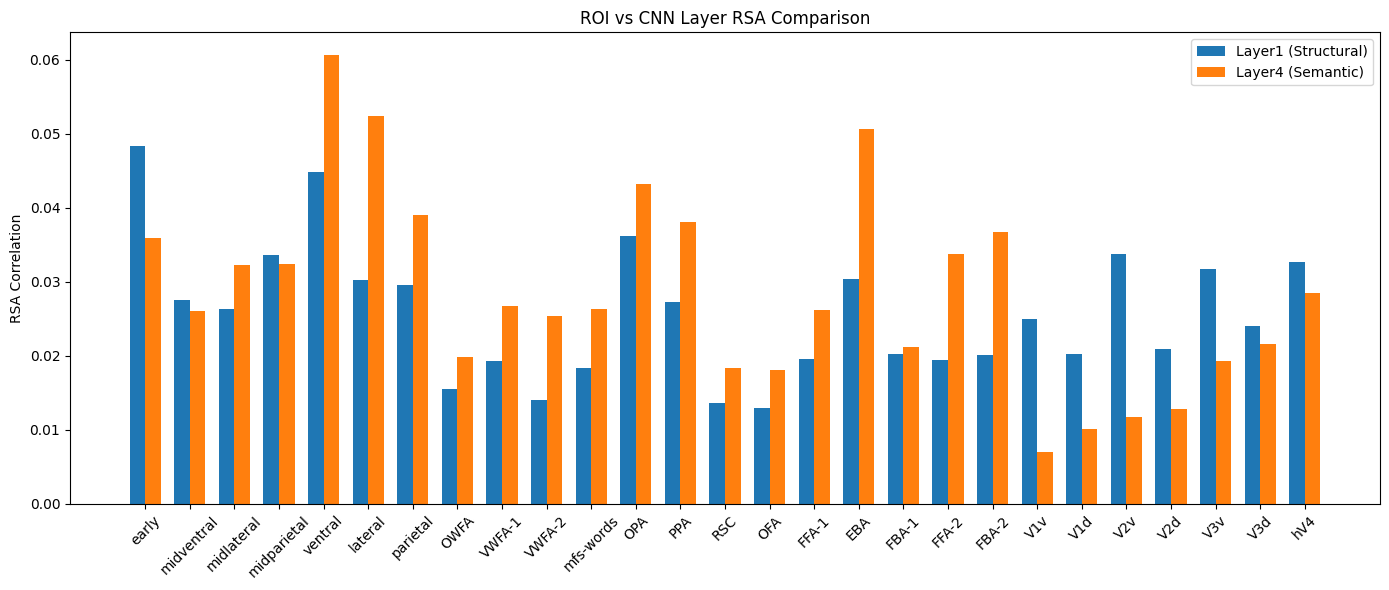

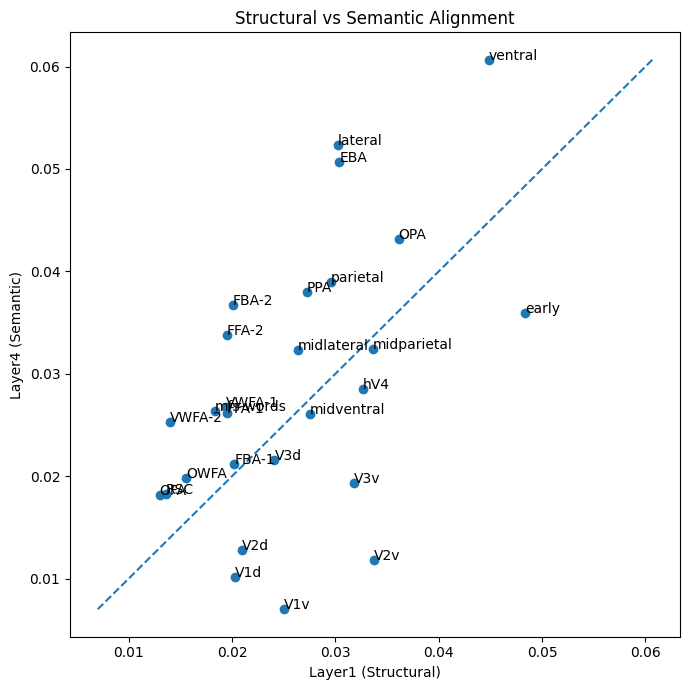

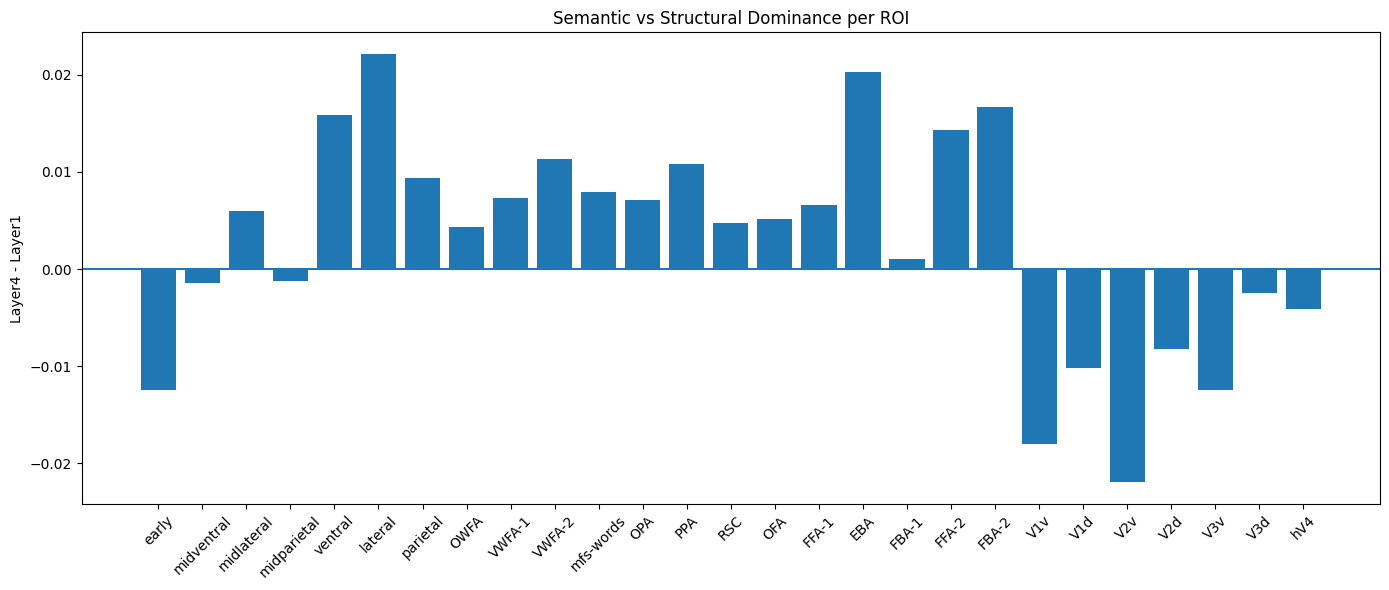


=== ROI INTERPRETATION ===

early                → STRUCTURAL (early vision) | L1=0.048, L4=0.036
midventral           → STRUCTURAL (early vision) | L1=0.027, L4=0.026
midlateral           → SEMANTIC (high-level vision) | L1=0.026, L4=0.032
midparietal          → STRUCTURAL (early vision) | L1=0.034, L4=0.032
ventral              → SEMANTIC (high-level vision) | L1=0.045, L4=0.061
lateral              → SEMANTIC (high-level vision) | L1=0.030, L4=0.052
parietal             → SEMANTIC (high-level vision) | L1=0.030, L4=0.039
OWFA                 → SEMANTIC (high-level vision) | L1=0.016, L4=0.020
VWFA-1               → SEMANTIC (high-level vision) | L1=0.019, L4=0.027
VWFA-2               → SEMANTIC (high-level vision) | L1=0.014, L4=0.025
mfs-words            → SEMANTIC (high-level vision) | L1=0.018, L4=0.026
OPA                  → SEMANTIC (high-level vision) | L1=0.036, L4=0.043
PPA                  → SEMANTIC (high-level vision) | L1=0.027, L4=0.038
RSC                  → SEMANTIC

In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt


SUBJECT = "subj01"
RESULT_FILE = f"{SUBJECT}_rsa_results.pkl"

with open(RESULT_FILE, "rb") as f:
    results = pickle.load(f)

rois = list(results.keys())

layer1_vals = [results[r]["layer1_structural"] for r in rois]
layer4_vals = [results[r]["layer4_semantic"] for r in rois]


x = np.arange(len(rois))
width = 0.35

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, layer1_vals, width, label="Layer1 (Structural)")
plt.bar(x + width/2, layer4_vals, width, label="Layer4 (Semantic)")

plt.xticks(x, rois, rotation=45)
plt.ylabel("RSA Correlation")
plt.title("ROI vs CNN Layer RSA Comparison")
plt.legend()

plt.tight_layout()
plt.savefig(f"{SUBJECT}_rsa_barplot.png")
plt.show()


plt.figure(figsize=(7, 7))

plt.scatter(layer1_vals, layer4_vals)

for i, roi in enumerate(rois):
    plt.text(layer1_vals[i], layer4_vals[i], roi)


min_val = min(layer1_vals + layer4_vals)
max_val = max(layer1_vals + layer4_vals)

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Layer1 (Structural)")
plt.ylabel("Layer4 (Semantic)")
plt.title("Structural vs Semantic Alignment")

plt.tight_layout()
plt.savefig(f"{SUBJECT}_rsa_scatter.png")
plt.show()


diff = np.array(layer4_vals) - np.array(layer1_vals)

plt.figure(figsize=(14, 6))
plt.bar(rois, diff)

plt.axhline(0)  

plt.xticks(rotation=45)
plt.ylabel("Layer4 - Layer1")
plt.title("Semantic vs Structural Dominance per ROI")

plt.tight_layout()
plt.savefig(f"{SUBJECT}_rsa_difference.png")
plt.show()


print("\n=== ROI INTERPRETATION ===\n")

for roi in rois:
    l1 = results[roi]["layer1_structural"]
    l4 = results[roi]["layer4_semantic"]

    if l1 > l4:
        label = "STRUCTURAL (early vision)"
    else:
        label = "SEMANTIC (high-level vision)"

    print(f"{roi:20s} → {label} | L1={l1:.3f}, L4={l4:.3f}")

In [11]:
import numpy as np
import pickle
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

SUBJECT = "subj01"

CNN_FEATURE_FILE = "resnet_conv3_features.pkl"
CNN_PCA_FILE = "resnet_conv3_pca.pkl"

PCA_TABLE_FILE = f"{SUBJECT}_pca_tables.pkl"
TOP40_FILE = f"{SUBJECT}_top40_clip.pkl"


with open(CNN_FEATURE_FILE, "rb") as f:
    cnn_data = pickle.load(f)

with open(PCA_TABLE_FILE, "rb") as f:
    pca_tables = pickle.load(f)

with open(TOP40_FILE, "rb") as f:
    top40 = pickle.load(f)

cnn_l1 = cnn_data["layer1_conv3"]
cnn_l4 = cnn_data["layer4_conv3"]

print("CNN shapes:", cnn_l1.shape, cnn_l4.shape)


def normalize(x):
    return (x - x.mean(axis=0)) / (x.std(axis=0) + 1e-8)

cnn_l1 = normalize(cnn_l1)
cnn_l4 = normalize(cnn_l4)

print("\nApplying PCA on CNN...")

scaler = StandardScaler()

cnn_l1_scaled = scaler.fit_transform(cnn_l1)
cnn_l4_scaled = scaler.fit_transform(cnn_l4)

pca_l1 = PCA(n_components=200)
pca_l4 = PCA(n_components=200)

cnn_l1_pca = pca_l1.fit_transform(cnn_l1_scaled)
cnn_l4_pca = pca_l4.fit_transform(cnn_l4_scaled)

cnn_l1_pca = normalize(cnn_l1_pca)
cnn_l4_pca = normalize(cnn_l4_pca)

cnn_pca_data = {
    "l1_pca": cnn_l1_pca,
    "l4_pca": cnn_l4_pca,
    "pca_l1_model": pca_l1,
    "pca_l4_model": pca_l4
}

with open(CNN_PCA_FILE, "wb") as f:
    pickle.dump(cnn_pca_data, f)

print("Saved CNN PCA")


results_channel = {}
results_pca = {}

for roi in tqdm(pca_tables.keys()):

    if roi not in top40:
        continue

    df = pca_tables[roi]

    roi_data = df.drop(columns=["subject", "roi", "image_path"]).values
    roi_data = normalize(roi_data)

    pcs = [int(pc.replace("PC", "")) - 1 for pc in top40[roi].keys()]
    roi_top = roi_data[:, pcs]

    roi_channel = {}
    roi_pca_match = {}

    for i, pc_idx in enumerate(pcs):

        vec = roi_top[:, i]

        corr_l1 = np.dot(vec, cnn_l1) / len(vec)
        corr_l4 = np.dot(vec, cnn_l4) / len(vec)

        combined = np.concatenate([corr_l1, corr_l4])
        sorted_idx = np.argsort(combined)[::-1]

        top_idx = sorted_idx[:20]
        top_vals = combined[top_idx]

        channel_results = []

        for idx, val in zip(top_idx, top_vals):
            if idx < 256:
                layer = "L1"
                comp_id = int(idx)
            else:
                layer = "L4"
                comp_id = int(idx - 256)

            channel_results.append({
                "layer": layer,
                "component": comp_id,
                "correlation": float(val)
            })

        roi_channel[f"PC{pc_idx+1}"] = channel_results


        corr_l1_p = np.dot(vec, cnn_l1_pca) / len(vec)
        corr_l4_p = np.dot(vec, cnn_l4_pca) / len(vec)

        combined_p = np.concatenate([corr_l1_p, corr_l4_p])
        sorted_idx_p = np.argsort(combined_p)[::-1]

        top_idx_p = sorted_idx_p[:20]
        top_vals_p = combined_p[top_idx_p]

        pca_results = []

        for idx, val in zip(top_idx_p, top_vals_p):
            if idx < 200:
                layer = "L1_PCA"
                comp_id = int(idx)
            else:
                layer = "L4_PCA"
                comp_id = int(idx - 200)

            pca_results.append({
                "layer": layer,
                "component": comp_id,
                "correlation": float(val)
            })

        roi_pca_match[f"PC{pc_idx+1}"] = pca_results

    results_channel[roi] = roi_channel
    results_pca[roi] = roi_pca_match


with open(f"{SUBJECT}_roi_to_cnn_channel.pkl", "wb") as f:
    pickle.dump(results_channel, f)

with open(f"{SUBJECT}_roi_to_cnn_pca.pkl", "wb") as f:
    pickle.dump(results_pca, f)

print("\nALL DONE (with correlation values saved)")

CNN shapes: (7000, 256) (7000, 2048)

Applying PCA on CNN...
Saved CNN PCA


1


ALL DONE (with correlation values saved)


In [12]:
import pickle
import numpy as np

SUBJECT = "subj01"




with open("resnet_conv3_features.pkl", "rb") as f:
    cnn = pickle.load(f)

l1 = cnn["layer1_conv3"]
l4 = cnn["layer4_conv3"]

print("Layer1 shape:", l1.shape)   
print("Layer4 shape:", l4.shape)  

print("Sample L1 row:", l1[0][:5])
print("Sample L4 row:", l4[0][:5])



print("\nCHECK: CNN PCA")

with open("resnet_conv3_pca.pkl", "rb") as f:
    cnn_pca = pickle.load(f)

l1_pca = cnn_pca["l1_pca"]
l4_pca = cnn_pca["l4_pca"]

print("Layer1 PCA shape:", l1_pca.shape)   
print("Layer4 PCA shape:", l4_pca.shape)

print("Sample PCA row:", l1_pca[0][:5])


print("\nCHECK: ROI → CNN CHANNEL")

with open(f"{SUBJECT}_roi_to_cnn_channel.pkl", "rb") as f:
    roi_channel = pickle.load(f)

print("Total ROIs:", len(roi_channel))


roi_name = list(roi_channel.keys())[0]
print("\nExample ROI:", roi_name)

example_pc = list(roi_channel[roi_name].keys())[0]

print("Example PC:", example_pc)
print("Top channels:", roi_channel[roi_name][example_pc][:10])



print("\n CHECK: ROI → CNN PCA ")

with open(f"{SUBJECT}_roi_to_cnn_pca.pkl", "rb") as f:
    roi_pca = pickle.load(f)

print("Total ROIs:", len(roi_pca))

roi_name = list(roi_pca.keys())[0]
example_pc = list(roi_pca[roi_name].keys())[0]

print("\nExample ROI:", roi_name)
print("Example PC:", example_pc)
print("Top PCA components:", roi_pca[roi_name][example_pc][:10])



print("\nCHECK: TOP 40 PCs")

with open(f"{SUBJECT}_top40_clip.pkl", "rb") as f:
    top40 = pickle.load(f)

roi_name = list(top40.keys())[0]

print("Example ROI:", roi_name)
print("Top PCs:", list(top40[roi_name].keys())[:10])



print("\nCHECK: PCA TABLES")

with open(f"{SUBJECT}_pca_tables.pkl", "rb") as f:
    pca_tables = pickle.load(f)

roi_name = list(pca_tables.keys())[0]

df = pca_tables[roi_name]

print("Example ROI:", roi_name)
print("Shape:", df.shape)
print("Columns:", df.columns[:10])
print("First row:\n", df.iloc[0][:10])

Layer1 shape: (7000, 256)
Layer4 shape: (7000, 2048)
Sample L1 row: [-0.00133288 -0.00292723 -0.07244521 -0.00029802  0.0449412 ]
Sample L4 row: [-0.01968618 -0.02977826 -0.00433153  0.01296921  0.01720129]

CHECK: CNN PCA
Layer1 PCA shape: (7000, 200)
Layer4 PCA shape: (7000, 200)
Sample PCA row: [ 0.90362805 -0.79885185 -0.9498929   1.0469117  -0.5720344 ]

CHECK: ROI → CNN CHANNEL
Total ROIs: 27

Example ROI: early
Example PC: PC43
Top channels: [{'layer': 'L1', 'component': 119, 'correlation': 0.10495071113109589}, {'layer': 'L4', 'component': 1574, 'correlation': 0.08823703229427338}, {'layer': 'L1', 'component': 110, 'correlation': 0.07979786396026611}, {'layer': 'L1', 'component': 224, 'correlation': 0.07947657257318497}, {'layer': 'L1', 'component': 50, 'correlation': 0.07740353792905807}, {'layer': 'L4', 'component': 1682, 'correlation': 0.07724664360284805}, {'layer': 'L4', 'component': 1442, 'correlation': 0.07505054771900177}, {'layer': 'L4', 'component': 846, 'correlation'

In [16]:
import pickle
import numpy as np

SUBJECT = "subj01"

# =========================
# LOAD FILES
# =========================
with open("resnet_conv3_pca.pkl", "rb") as f:
    cnn_pca = pickle.load(f)

with open(f"{SUBJECT}_pca_tables.pkl", "rb") as f:
    pca_tables = pickle.load(f)

with open(f"{SUBJECT}_roi_to_cnn_pca.pkl", "rb") as f:
    mapping = pickle.load(f)

# =========================
# PICK ROI + PC
# =========================
roi_name = list(mapping.keys())[0]
pc_name = "PC3"

print("\nSelected ROI:", roi_name)
print("Selected PC:", pc_name)

entries = mapping[roi_name][pc_name]

# =========================
# CASE 1: NEW FORMAT (with correlation)
# =========================
if isinstance(entries[0], dict):

    print("\nTop CNN PCA components (from saved results):\n")

    for i, item in enumerate(entries[:50]):   # print top 50

        layer = item["layer"]
        comp_id = item["component"]
        val = item["correlation"]

        print(f"{i+1:2d}. {layer} Component {comp_id:3d} → Corr = {val:.4f}")

# =========================
# CASE 2: OLD FORMAT (fallback → recompute)
# =========================
else:
    print("\n⚠️ Old format detected → recomputing correlations\n")

    cnn_l1_pca = cnn_pca["l1_pca"]
    cnn_l4_pca = cnn_pca["l4_pca"]

    cnn_combined = np.concatenate([cnn_l1_pca, cnn_l4_pca], axis=1)

    pc_idx = int(pc_name.replace("PC", "")) - 1

    df = pca_tables[roi_name]
    roi_data = df.drop(columns=["subject", "roi", "image_path"]).values

    pc_vector = roi_data[:, pc_idx]

    corr = np.dot(pc_vector, cnn_combined) / len(pc_vector)
    sorted_idx = np.argsort(corr)[::-1]

    print("\nTop CNN PCA components (recomputed):\n")

    for i in range(50):
        idx = sorted_idx[i]
        val = corr[idx]

        if idx < 200:
            layer = "L1_PCA"
            comp_id = idx
        else:
            layer = "L4_PCA"
            comp_id = idx - 200

        print(f"{i+1:2d}. {layer} Component {comp_id:3d} → Corr = {val:.4f}")


Selected ROI: early
Selected PC: PC3

Top CNN PCA components (from saved results):

 1. L1_PCA Component   0 → Corr = 0.2689
 2. L4_PCA Component   2 → Corr = 0.1022
 3. L1_PCA Component   7 → Corr = 0.0783
 4. L4_PCA Component  23 → Corr = 0.0652
 5. L4_PCA Component  24 → Corr = 0.0508
 6. L1_PCA Component  83 → Corr = 0.0498
 7. L4_PCA Component 185 → Corr = 0.0465
 8. L1_PCA Component  80 → Corr = 0.0440
 9. L1_PCA Component  23 → Corr = 0.0427
10. L1_PCA Component  60 → Corr = 0.0411
11. L4_PCA Component  29 → Corr = 0.0392
12. L4_PCA Component 157 → Corr = 0.0382
13. L1_PCA Component 159 → Corr = 0.0382
14. L1_PCA Component  77 → Corr = 0.0363
15. L1_PCA Component 130 → Corr = 0.0360
16. L1_PCA Component  12 → Corr = 0.0358
17. L4_PCA Component 184 → Corr = 0.0353
18. L1_PCA Component 174 → Corr = 0.0347
19. L1_PCA Component  47 → Corr = 0.0345
20. L1_PCA Component  89 → Corr = 0.0343


In [20]:
import os
import pickle
import numpy as np

# =========================
# CONFIG
# =========================
SUBJECT = "subj01"
TOP_K = 20

CNN_PCA_FILE = "resnet_conv3_pca.pkl"
IMAGE_DIR = "subj01/training_split/training_images"

OUT_TOP_IMAGES = f"{SUBJECT}_cnn_top_images.pkl"

# =========================
# LOAD CNN PCA
# =========================
with open(CNN_PCA_FILE, "rb") as f:
    cnn_pca = pickle.load(f)

cnn_l1_pca = cnn_pca["l1_pca"]   # (7000, 200)
cnn_l4_pca = cnn_pca["l4_pca"]   # (7000, 200)

cnn_combined = np.concatenate([cnn_l1_pca, cnn_l4_pca], axis=1)  # (7000, 400)

print("CNN shape:", cnn_combined.shape)

# =========================
# LOAD IMAGE PATHS
# =========================
image_files = [
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
    and not f.startswith(".")
]

image_files.sort()
image_files = image_files[:7000]

image_paths = [os.path.join(IMAGE_DIR, f) for f in image_files]

# =========================
# EXTRACT TOP IMAGES
# =========================
cnn_top_images = {}

for comp_idx in range(cnn_combined.shape[1]):

    values = cnn_combined[:, comp_idx]
    sorted_idx = np.argsort(values)[::-1]
    top_idx = sorted_idx[:TOP_K]

    if comp_idx < 200:
        comp_name = f"L1_PCA_PC{comp_idx + 1}"   # ✅ FIXED
    else:
        comp_name = f"L4_PCA_PC{(comp_idx - 200) + 1}"   # ✅ FIXED

    cnn_top_images[comp_name] = {
        "image_paths": [image_paths[i] for i in top_idx],
        "scores": values[top_idx].tolist()
    }

print("Extracted top images")

with open(OUT_TOP_IMAGES, "wb") as f:
    pickle.dump(cnn_top_images, f)

print("Saved:", OUT_TOP_IMAGES)

C:\Users\tanma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


CNN shape: (7000, 400)
Extracted top images
Saved: subj01_cnn_top_images.pkl


In [23]:
print(cnn_top_images)

{'L1_PCA_PC1': {'image_paths': ['subj01/training_split/training_images\\train-0204_nsd-01632.png', 'subj01/training_split/training_images\\train-6800_nsd-50622.png', 'subj01/training_split/training_images\\train-5980_nsd-44355.png', 'subj01/training_split/training_images\\train-3110_nsd-23731.png', 'subj01/training_split/training_images\\train-6477_nsd-48074.png', 'subj01/training_split/training_images\\train-0108_nsd-00908.png', 'subj01/training_split/training_images\\train-1327_nsd-10262.png', 'subj01/training_split/training_images\\train-4989_nsd-37179.png', 'subj01/training_split/training_images\\train-0888_nsd-06903.png', 'subj01/training_split/training_images\\train-1519_nsd-11668.png', 'subj01/training_split/training_images\\train-1945_nsd-14955.png', 'subj01/training_split/training_images\\train-3393_nsd-25740.png', 'subj01/training_split/training_images\\train-5090_nsd-37897.png', 'subj01/training_split/training_images\\train-6527_nsd-48480.png', 'subj01/training_split/trainin

In [2]:
import os
import json
import pickle
import ollama
import re
import time

# =========================
# CONFIG
# =========================
VISION_MODEL = "llava"
CLEAN_MODEL = "phi3:mini"

MAX_RETRIES = 3

INPUT_PKL = "subj01_cnn_top_images.pkl"
OUTPUT_JSON = "final_concepts.json"

# =========================
# LOAD DATA
# =========================
with open(INPUT_PKL, "rb") as f:
    data = pickle.load(f)

print("Total components:", len(data))

# =========================
# RESUME SUPPORT
# =========================
if os.path.exists(OUTPUT_JSON):
    with open(OUTPUT_JSON, "r") as f:
        results = json.load(f)
else:
    results = {}

# =========================
# WORD CLEANING
# =========================
STOPWORDS = {
    "this","that","these","those","there","here",
    "you","your","they","them","their",
    "it","its","we","our",
    "is","are","was","were","be","been","being",
    "have","has","had","do","does","did",
    "image","images","photo","picture",
    "thing","object","objects",
    "show","shows","showing",
    "and","or","with","from","into","over","under",
    "the","a","an","of","in","on","at"
}

def extract_words(text):
    words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
    words = list(dict.fromkeys(words))
    words = [w for w in words if w not in STOPWORDS]
    return words

# =========================
# CLEAN WITH SMALL LLM
# =========================
def clean_with_llm(text):

    prompt = f"""Extract EXACTLY 5 meaningful visual nouns from this text.

Rules:
Only nouns (objects, places, things)
No verbs
No filler words
No explanation
Exactly 5 words

Text:
{text}

Answer:
"""

    try:
        res = ollama.chat(
            model=CLEAN_MODEL,
            messages=[{
                "role": "user",
                "content": prompt
            }]
        )

        output = res["message"]["content"]
        print("Cleaner output:", output)

        words = extract_words(output)

        if len(words) >= 5:
            return words[:5]

    except Exception as e:
        print("Cleaner error:", e)

    return None

# =========================
# MAIN PIPELINE
# =========================
def caption_component(comp, images):

    print("\n" + "="*60)
    print(f"Processing: {comp}")
    print(f"Images used: {len(images)}")

    for attempt in range(MAX_RETRIES):

        print(f"\nAttempt {attempt+1}")

        try:
            # STEP 1: LLaVA (vision)
            res = ollama.chat(
                model=VISION_MODEL,
                messages=[{
                    "role": "user",
                    "content": "Describe what is common across these images in one sentence.",
                    "images": images
                }]
            )

            raw_text = res["message"]["content"]
            print("LLaVA output:", raw_text)

            # STEP 2: CLEANER LLM
            cleaned = clean_with_llm(raw_text)

            if cleaned:
                print("✅ FINAL CONCEPTS:", cleaned)
                return cleaned

            print("⚠️ Cleaning failed, retrying...")

        except Exception as e:
            print("❌ Error:", e)

        time.sleep(1)

    print("❌ FAILED:", comp)
    return None

# =========================
# PROCESS LOOP
# =========================
failed = []

for i, (comp, info) in enumerate(data.items()):

    print(f"\n\n########## {i+1}/{len(data)} ##########")

    if comp in results:
        print("Skipping (already done)")
        continue

    images = info["image_paths"][:10]

    captions = caption_component(comp, images)

    if captions:
        results[comp] = {
            "images": info["image_paths"],
            "concepts": captions
        }
    else:
        failed.append(comp)

    # SAVE PROGRESS
    with open(OUTPUT_JSON, "w") as f:
        json.dump(results, f, indent=2)

# =========================
# FINAL REPORT
# =========================
print("\n===== DONE =====")
print("Saved:", len(results))
print("Failed:", len(failed))

if failed:
    print("Failed examples:", failed[:20])

Total components: 400


########## 1/400 ##########

Processing: L1_PCA_PC1
Images used: 10

Attempt 1
LLaVA output:  These are two photos: In the first photo, a person is flying a small kite over the ocean on a sunny day. In the second photo, an identical airplane-like aircraft is flying above the ocean under dark, stormy clouds on a different day with the same person standing next to it. 
Cleaner output: person,kite,ocean,airplane,clouds
✅ FINAL CONCEPTS: ['person', 'kite', 'ocean', 'airplane', 'clouds']


########## 2/400 ##########

Processing: L1_PCA_PC2
Images used: 10

Attempt 1
LLaVA output:  This image is a square collage of two photos featuring the same man with a dog and bananas in both, suggesting that it might be a humorous or thematic representation of the person's lifestyle or hobby. 
Cleaner output: 1. Square collage
2. Photos
3. Man
4. Dog
5. Bananas
✅ FINAL CONCEPTS: ['square', 'collage', 'photos', 'man', 'dog']


########## 3/400 ##########

Processing: L1_PCA_PC3
Im

In [2]:
import json

with open("final_concepts.json") as f:
    caps = json.load(f)

print(caps)

print("Total CNN captions:", len(caps))

{'L1_PCA_PC1': {'images': ['subj01/training_split/training_images\\train-0204_nsd-01632.png', 'subj01/training_split/training_images\\train-6800_nsd-50622.png', 'subj01/training_split/training_images\\train-5980_nsd-44355.png', 'subj01/training_split/training_images\\train-3110_nsd-23731.png', 'subj01/training_split/training_images\\train-6477_nsd-48074.png', 'subj01/training_split/training_images\\train-0108_nsd-00908.png', 'subj01/training_split/training_images\\train-1327_nsd-10262.png', 'subj01/training_split/training_images\\train-4989_nsd-37179.png', 'subj01/training_split/training_images\\train-0888_nsd-06903.png', 'subj01/training_split/training_images\\train-1519_nsd-11668.png', 'subj01/training_split/training_images\\train-1945_nsd-14955.png', 'subj01/training_split/training_images\\train-3393_nsd-25740.png', 'subj01/training_split/training_images\\train-5090_nsd-37897.png', 'subj01/training_split/training_images\\train-6527_nsd-48480.png', 'subj01/training_split/training_ima

In [9]:
import json
import pickle
import numpy as np
import torch
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm

# =========================
# CONFIG
# =========================
SUBJECT = "subj01"

FMRI_CAPTIONS_FILE = "captions_subj01.json"
CNN_CAPTIONS_FILE  = "final_concepts.json"
MAPPING_FILE = f"{SUBJECT}_roi_to_cnn_pca.pkl"

OUTPUT_FILE = f"{SUBJECT}_semantic_alignment_clip.pkl"

DEVICE = "mps" if torch.backends.mps.is_available() else \
         "cuda" if torch.cuda.is_available() else "cpu"

TOP_K_PAIRS = 10

# =========================
# LOAD DATA
# =========================
print("Loading data...")

with open(FMRI_CAPTIONS_FILE, "r") as f:
    fmri_caps = json.load(f)

with open(CNN_CAPTIONS_FILE, "r") as f:
    cnn_caps = json.load(f)

with open(MAPPING_FILE, "rb") as f:
    mapping = pickle.load(f)

# =========================
# LOAD CLIP
# =========================
print("Loading CLIP model...")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model.eval()

# =========================
# HELPER: TEXT EMBEDDING
# =========================
def get_text_embedding(words):
    inputs = processor(
        text=words,
        return_tensors="pt",
        padding=True,
        truncation=True
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model.text_model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"]
        )

        # ✅ correct CLIP text embedding
        emb = outputs.pooler_output   # (batch_size, hidden_dim)

        # project to CLIP space
        emb = model.text_projection(emb)

    # normalize
    emb = emb / emb.norm(dim=-1, keepdim=True)

    return emb.cpu().numpy()

# =========================
# PRECOMPUTE EMBEDDINGS
# =========================
print("Precomputing CLIP embeddings...")

fmri_emb_cache = {}
cnn_emb_cache = {}

# -------- fMRI --------
for key in fmri_caps:   # key = "early__PC1"
    captions = fmri_caps[key].get("captions", [])

    if captions and len(captions) >= 5:
        fmri_emb_cache[key] = get_text_embedding(captions[:5])

# -------- CNN --------
for key in cnn_caps:    # key = "layer_PCx"
    captions = cnn_caps[key].get("captions", [])

    if captions and len(captions) >= 5:
        cnn_emb_cache[key] = get_text_embedding(captions[:5])

# =========================
# COSINE SIMILARITY
# =========================
def cosine_matrix(A, B):
    return np.dot(A, B.T)

# =========================
# MAIN LOOP
# =========================
print("\nRunning semantic alignment...\n")

results = {}

for roi in tqdm(mapping.keys()):

    results[roi] = {}

    for pc in mapping[roi]:

        fmri_key = f"{roi}__{pc}"

        if fmri_key not in fmri_emb_cache:
            continue

        fmri_words = fmri_caps[fmri_key]["captions"][:5]
        fmri_emb   = fmri_emb_cache[fmri_key]

        results[roi][pc] = []

        for cnn_item in mapping[roi][pc]:

            layer = cnn_item["layer"]
            comp  = cnn_item["component"]

            cnn_key = f"{layer}_PC{comp}"

            if cnn_key not in cnn_emb_cache:
                continue

            cnn_words = cnn_caps[cnn_key]["captions"][:5]
            cnn_emb   = cnn_emb_cache[cnn_key]

            # =========================
            # SIMILARITY MATRIX (5x5)
            # =========================
            sim_matrix = cosine_matrix(fmri_emb, cnn_emb)

            pairs = []

            for i in range(len(fmri_words)):
                for j in range(len(cnn_words)):
                    pairs.append({
                        "fmri_word": fmri_words[i],
                        "cnn_word": cnn_words[j],
                        "similarity": float(sim_matrix[i, j])
                    })

            # sort descending
            pairs.sort(key=lambda x: x["similarity"], reverse=True)

            results[roi][pc].append({
                "cnn_component": cnn_key,
                "top_pairs": pairs[:TOP_K_PAIRS]
            })

# =========================
# SAVE OUTPUT
# =========================
with open(OUTPUT_FILE, "wb") as f:
    pickle.dump(results, f)

print("\n✅ DONE — CLIP semantic alignment complete!")

Loading data...
Loading CLIP model...


Loading weights: 100%|████████████████████████████████████████████████████████████| 398/398 [00:00<00:00, 28294.74it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Precomputing CLIP embeddings...

Running semantic alignment...



100%|████████████████████████████████████████████████████████████████████████████████| 27/27 [00:00<00:00, 2250.48it/s]


✅ DONE — CLIP semantic alignment complete!


In [10]:
import pickle
import json

FILE = "subj01_semantic_alignment_clip.pkl"

# =========================
# LOAD DATA
# =========================
with open(FILE, "rb") as f:
    data = pickle.load(f)

print("✅ Loaded successfully!")
print("="*50)

# =========================
# BASIC INFO
# =========================
num_rois = len(data)
num_pcs = sum(len(data[roi]) for roi in data)

print(f"Total ROIs: {num_rois}")
print(f"Total PCs: {num_pcs}")

# =========================
# PRINT STRUCTURE
# =========================
print("\n🔍 STRUCTURE SAMPLE\n")

for roi in data:
    print("ROI:", roi)

    for pc in data[roi]:
        print("  PC:", pc)

        if len(data[roi][pc]) > 0:
            sample = data[roi][pc][0]

            print("    CNN Component:", sample["cnn_component"])
            print("    Example pair:", sample["top_pairs"][0])

        break
    break

# =========================
# PRINT TOP MATCHES (SAMPLE)
# =========================
print("\n🔥 SAMPLE ALIGNMENTS\n")

count = 0
for roi in data:
    for pc in data[roi]:

        print(f"\n=== ROI: {roi} | PC: {pc} ===")

        for item in data[roi][pc][:2]:  # show 2 CNN components
            print("\nCNN:", item["cnn_component"])

            for pair in item["top_pairs"][:5]:  # top 5 pairs
                print(f"{pair['fmri_word']:15} <--> {pair['cnn_word']:15} | {pair['similarity']:.3f}")

        count += 1
        if count >= 3:   # limit output
            break
    if count >= 3:
        break

# =========================
# FIND BEST MATCH PER PC
# =========================
print("\n🏆 BEST MATCH PER PC\n")

for roi in data:
    for pc in data[roi]:

        best_score = -1
        best_pair = None
        best_cnn = None

        for item in data[roi][pc]:
            for pair in item["top_pairs"]:
                if pair["similarity"] > best_score:
                    best_score = pair["similarity"]
                    best_pair = pair
                    best_cnn = item["cnn_component"]

        if best_pair:
            print(f"{roi} | {pc}")
            print(f"  BEST CNN: {best_cnn}")
            print(f"  {best_pair['fmri_word']} <--> {best_pair['cnn_word']} ({best_score:.3f})\n")

# =========================
# SAVE READABLE JSON
# =========================
OUTPUT_JSON = "semantic_alignment_readable.json"

with open(OUTPUT_JSON, "w") as f:
    json.dump(data, f, indent=2)

print("💾 Saved readable JSON:", OUTPUT_JSON)

✅ Loaded successfully!
Total ROIs: 27
Total PCs: 1080

🔍 STRUCTURE SAMPLE

ROI: early
  PC: PC43

🔥 SAMPLE ALIGNMENTS


=== ROI: early | PC: PC43 ===

=== ROI: early | PC: PC190 ===

=== ROI: early | PC: PC100 ===

🏆 BEST MATCH PER PC

💾 Saved readable JSON: semantic_alignment_readable.json


In [1]:
import pickle

FILE = "subj01_semantic_alignment_clip.pkl"

# =========================
# LOAD
# =========================
with open(FILE, "rb") as f:
    data = pickle.load(f)

print("✅ File Loaded\n")

# =========================
# BASIC INFO
# =========================
print("Top-level type:", type(data))

roi_keys = list(data.keys())
print("\nNumber of ROIs:", len(roi_keys))
print("Sample ROIs:", roi_keys[:5])

# =========================
# COUNT EMPTY vs NON-EMPTY
# =========================
empty_count = 0
non_empty_count = 0
total = 0

for roi in data:
    for pc in data[roi]:
        total += 1
        if len(data[roi][pc]) == 0:
            empty_count += 1
        else:
            non_empty_count += 1

print("\n📊 DATA HEALTH:")
print(f"Total PCs: {total}")
print(f"Non-empty PCs: {non_empty_count}")
print(f"Empty PCs: {empty_count}")

# =========================
# FIND FIRST VALID ENTRY
# =========================
found = False

for roi in data:
    for pc in data[roi]:

        cnn_list = data[roi][pc]

        if len(cnn_list) > 0:
            print("\n✅ FOUND VALID ENTRY")
            print("ROI:", roi)
            print("PC:", pc)

            print("\nNumber of CNN components:", len(cnn_list))

            cnn_item = cnn_list[0]

            print("\n👉 CNN ENTRY STRUCTURE:")
            for k, v in cnn_item.items():
                print(f"{k}: type={type(v)}")

            # =========================
            # INSPECT TOP PAIRS
            # =========================
            if "top_pairs" in cnn_item and len(cnn_item["top_pairs"]) > 0:
                pair = cnn_item["top_pairs"][0]

                print("\n👉 SAMPLE PAIR:")
                for k, v in pair.items():
                    print(f"{k}: {v} (type={type(v)})")
            else:
                print("\n⚠️ No top_pairs found")

            found = True
            break

    if found:
        break

if not found:
    print("\n❌ No valid entries found in entire file!")

# =========================
# OPTIONAL: PRINT EMPTY PCs
# =========================
print("\n🔍 SAMPLE EMPTY PCs:")

count = 0
for roi in data:
    for pc in data[roi]:
        if len(data[roi][pc]) == 0:
            print(f"ROI={roi}, PC={pc}")
            count += 1
        if count == 10:
            break
    if count == 10:
        break

# =========================
# FINAL STRUCTURE SUMMARY
# =========================
print("\n\n📊 EXPECTED STRUCTURE:\n")

print("""
data (dict)
 ├── roi (str)
 │    ├── pc (str)
 │    │    ├── list of CNN components (can be empty ⚠️)
 │    │    │    ├── dict:
 │    │    │    │    ├── cnn_component (str/int)
 │    │    │    │    ├── top_pairs (list)
 │    │    │    │    │    ├── dict:
 │    │    │    │    │    │    ├── fmri_word (str)
 │    │    │    │    │    │    ├── cnn_word (str)
 │    │    │    │    │    │    ├── similarity (float)
""")

✅ File Loaded

Top-level type: <class 'dict'>

Number of ROIs: 27
Sample ROIs: ['early', 'midventral', 'midlateral', 'midparietal', 'ventral']

📊 DATA HEALTH:
Total PCs: 1080
Non-empty PCs: 0
Empty PCs: 1080

❌ No valid entries found in entire file!

🔍 SAMPLE EMPTY PCs:
ROI=early, PC=PC43
ROI=early, PC=PC190
ROI=early, PC=PC100
ROI=early, PC=PC4
ROI=early, PC=PC3
ROI=early, PC=PC173
ROI=early, PC=PC85
ROI=early, PC=PC187
ROI=early, PC=PC104
ROI=early, PC=PC102


📊 EXPECTED STRUCTURE:


data (dict)
 ├── roi (str)
 │    ├── pc (str)
 │    │    ├── list of CNN components (can be empty ⚠️)
 │    │    │    ├── dict:
 │    │    │    │    ├── cnn_component (str/int)
 │    │    │    │    ├── top_pairs (list)
 │    │    │    │    │    ├── dict:
 │    │    │    │    │    │    ├── fmri_word (str)
 │    │    │    │    │    │    ├── cnn_word (str)
 │    │    │    │    │    │    ├── similarity (float)



In [12]:
import pickle
import json

# =========================
# FILES
# =========================
CNN_TOP_IMAGES = "subj01_cnn_top_images.pkl"
CNN_CAPTIONS   = "final_concepts.json"
CLIP_OUTPUT    = "subj01_semantic_alignment_clip.pkl"
MAPPING_FILE   = "subj01_roi_to_cnn_pca.pkl"

# =========================
# LOAD
# =========================
with open(CNN_TOP_IMAGES, "rb") as f:
    cnn_top = pickle.load(f)

with open(CNN_CAPTIONS, "r") as f:
    cnn_caps = json.load(f)

with open(CLIP_OUTPUT, "rb") as f:
    clip_data = pickle.load(f)

with open(MAPPING_FILE, "rb") as f:
    mapping = pickle.load(f)

print("✅ All files loaded\n")

# =========================
# 1️⃣ CHECK CNN TOP IMAGES
# =========================
print("🔍 CHECK 1: CNN TOP IMAGES")

print("Total CNN components:", len(cnn_top))

# sample check
bad_count = 0

for k, v in cnn_top.items():
    if len(v["image_paths"]) != 20:
        bad_count += 1

print("Components with !=20 images:", bad_count)

# =========================
# 2️⃣ CHECK CNN CAPTIONS
# =========================
print("\n🔍 CHECK 2: CNN CAPTIONS")

print("Total captions:", len(cnn_caps))

missing_caps = set(cnn_top.keys()) - set(cnn_caps.keys())

print("Missing captions:", len(missing_caps))

if missing_caps:
    print("Sample missing:", list(missing_caps)[:5])

# =========================
# 3️⃣ CHECK MAPPING COVERAGE
# =========================
print("\n🔍 CHECK 3: MAPPING COVERAGE")

all_mapping_keys = set()

for roi in mapping:
    for pc in mapping[roi]:
        for item in mapping[roi][pc]:
            key = f"{item['layer']}_PC{item['component']}"
            all_mapping_keys.add(key)

print("Total mapping CNN keys:", len(all_mapping_keys))

missing_in_caps = all_mapping_keys - set(cnn_caps.keys())

print("Mapping keys missing in captions:", len(missing_in_caps))

# =========================
# 4️⃣ CHECK CLIP OUTPUT STRUCTURE
# =========================
print("\n🔍 CHECK 4: CLIP OUTPUT")

roi = list(clip_data.keys())[0]
pc  = list(clip_data[roi].keys())[0]

print(f"Sample ROI: {roi}")
print(f"Sample PC: {pc}")

num_cnn = len(clip_data[roi][pc])
print("CNN components per PC:", num_cnn)

# =========================
# 5️⃣ GLOBAL CLIP CHECK
# =========================
print("\n🔍 CHECK 5: GLOBAL CLIP COVERAGE")

counts = []

for roi in clip_data:
    for pc in clip_data[roi]:
        counts.append(len(clip_data[roi][pc]))

print("Min CNN per PC:", min(counts))
print("Max CNN per PC:", max(counts))
print("Average CNN per PC:", sum(counts)/len(counts))

# =========================
# FINAL VERDICT
# =========================
print("\n🚨 FINAL DIAGNOSIS\n")

if len(cnn_top) < 400:
    print("❌ CNN TOP IMAGES NOT COMPLETE")

elif len(cnn_caps) < 400:
    print("❌ CNN CAPTIONS NOT COMPLETE")

elif min(counts) < 300:
    print("❌ CLIP OUTPUT MISSING MANY CNN COMPONENTS")

else:
    print("✅ EVERYTHING IS CORRECT 🎉")

✅ All files loaded

🔍 CHECK 1: CNN TOP IMAGES
Total CNN components: 400
Components with !=20 images: 0

🔍 CHECK 2: CNN CAPTIONS
Total captions: 398
Missing captions: 2
Sample missing: ['L4_PCA_PC79', 'L4_PCA_PC181']

🔍 CHECK 3: MAPPING COVERAGE
Total mapping CNN keys: 400
Mapping keys missing in captions: 4

🔍 CHECK 4: CLIP OUTPUT
Sample ROI: early
Sample PC: PC43
CNN components per PC: 0

🔍 CHECK 5: GLOBAL CLIP COVERAGE
Min CNN per PC: 0
Max CNN per PC: 0
Average CNN per PC: 0.0

🚨 FINAL DIAGNOSIS

❌ CNN CAPTIONS NOT COMPLETE
